In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
path_2012 = r"H:\Python\Etapa3\Atividade6\Tabela5-sem_emprego_2012.csv"
path_2026 = r"H:\Python\Etapa3\Atividade6\Tabela5-sem_emprego_2026.csv"
path_horas = r"H:\Python\Etapa3\Atividade6\Tabela 1.1.1.xls"

In [7]:
tab_2012 = pd.read_csv(path_2012, encoding="utf8", sep=";", decimal=",")

In [8]:
tab_2012 = tab_2012.rename(columns = {"Desocupados - homens (2012 T1)" : "homens_2012"})

In [9]:
tab_2012 = tab_2012.rename(columns = {"Desocupados - mulheres (2012 T1)" : "mulheres_2012"})

In [10]:
tab_2012

,Sigla,Código,Estado,homens_2012,mulheres_2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [28]:
tab_2026 = pd.read_csv(path_2026, encoding="utf8", sep=";", decimal=",")

In [29]:
tab_2026 = tab_2026.rename(columns = {"Desocupados - homens (2026 T1)" : "homens_2026"})

In [30]:
tab_2026 = tab_2026.rename(columns = {"Desocupados - mulheres (2026 T1)" : "mulheres_2026"})

In [36]:
comp = tab_2012.merge(tab_2026, on = ["Sigla", "Código", "Estado"], how = "inner")

In [37]:
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [33]:
path = r"H:\Python\Etapa3\Atividade6\IndicadorMulheres\Tabela 1.1.1.xls"

In [34]:
# Lê sem usar a 1ª linha como nome de coluna (senão o título vira "coluna")
bruto = pd.read_excel(path, engine="xlrd", header=None)

# Linhas 0–7: título/cabeçalho  |  8–40: resultados  |  41+: fonte e notas
indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

In [35]:
regioes = ["Norte", "Noredeste", "Sudeste", "Sul", "Centrp-Oeste"]

estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]

In [38]:
estados = estados.rename(columns = {"uf_regiao": "Estado"})

In [41]:
estados 
comp = comp.merge(estados, on = "Estado", how = "inner")

In [42]:
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,AC,12,Acre,45.3,54.7,53.2,46.8,13.606903,13.806929,13.541399,10.79612,9.686983,16.130352,16.710754
1,AL,27,Alagoas,44.7,55.3,50.7,49.3,20.217129,19.165111,20.560451,12.121839,13.35716,24.093655,25.856637
2,AM,13,Amazonas,47.5,52.5,46.8,53.2,16.80729,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,AP,16,Amapá,48.1,51.9,51.1,48.9,13.586656,14.38918,13.415091,11.116821,10.749444,16.648579,15.908487
4,BA,29,Bahia,43.8,56.2,44.7,55.3,17.849776,17.538007,17.935566,10.551673,10.982808,22.57273,23.217119
5,CE,23,Ceará,51.1,48.9,52.7,47.3,19.499293,18.52712,19.882469,12.186936,12.821323,23.019718,24.952274
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1,15.096351,15.061306,15.126295,11.377952,10.481279,17.738123,19.307332
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5,17.111106,16.51061,17.478861,11.798571,12.017589,20.464462,22.196626
8,GO,52,Goiás,41.0,59.0,47.5,52.5,15.186471,14.962622,15.296966,10.636424,10.531883,18.440842,19.587913
9,MA,21,Maranhão,47.2,52.8,49.1,50.9,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589


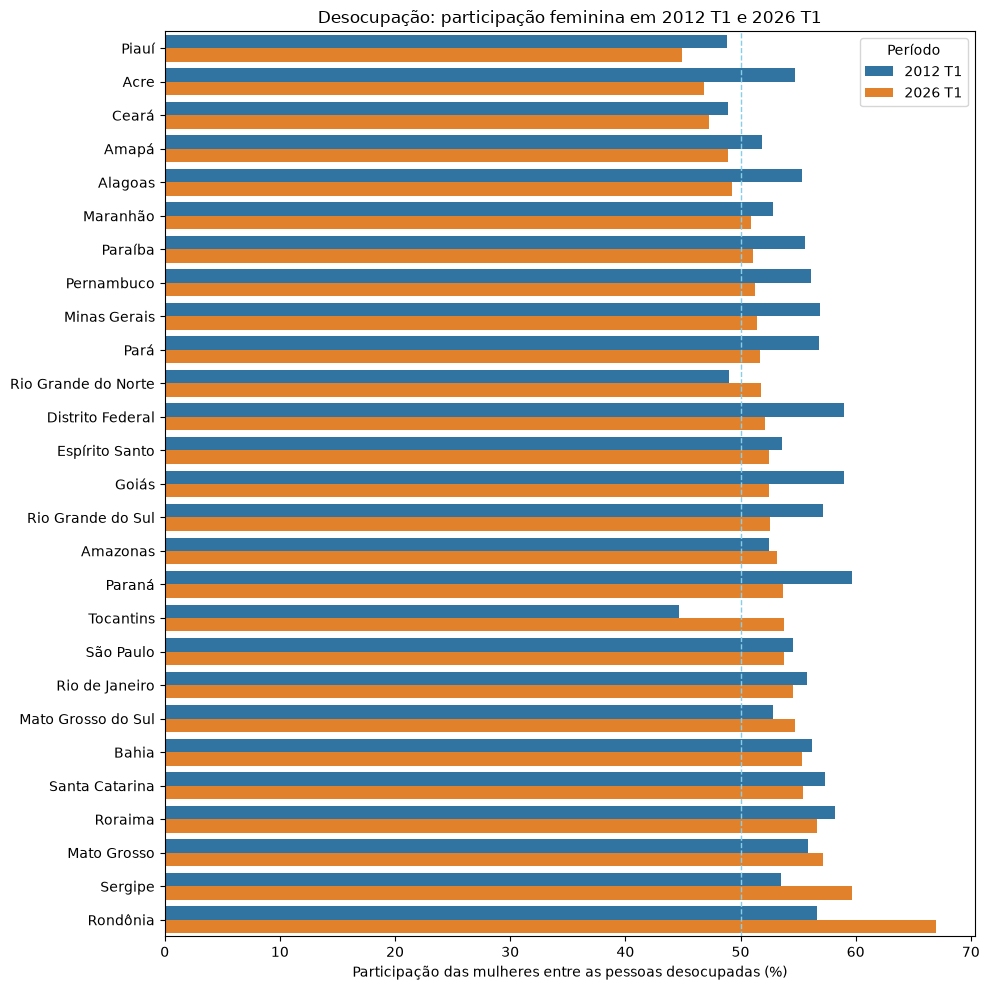

In [46]:
ordem = comp.sort_values("mulheres_2026")["Estado"]
longo = comp.melt(
    id_vars=["Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="skyblue", linestyle="--", linewidth=1) # MUDE A COR
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Período")
fig.tight_layout()